In [6]:
from pathlib import Path
import pandas as pd

In [22]:
root = Path("/home/shares/schaerm/schaer2/thibaut/humanlisbet/output/trained_models/real_train/tr/models/lisbet-tr-101225-embedder/embeddings/train")
out = root / "hierarchy_clustering"
out.mkdir(exist_ok=True)

In [23]:
segs = []
for i, folder in enumerate(root.iterdir()):
    if folder.is_dir():
        segs.append(pd.read_csv(folder / "features_lisbet_embedding.csv", index_col=0))
    # if i > 10:
        # break

print(f"Loaded {len(segs)} segments")
for i, seg in enumerate(segs):
    print(f"Segment {i}: {seg.shape}")

FileNotFoundError: [Errno 2] No such file or directory: '/home/shares/schaerm/schaer2/thibaut/humanlisbet/output/trained_models/real_train/tr/models/lisbet-tr-101225-embedder/embeddings/train/hierarchy_clustering/features_lisbet_embedding.csv'

In [ ]:
import numpy as np
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import pdist
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import matplotlib.pyplot as plt

## Exponential Smoothing
Apply exponential smoothing along the time axis to reduce noise while preserving sharp changes

Original shape: (1837, 256)
Smoothed shape: (1837, 256)


In [ ]:
# Apply exponential smoothing to each segment
segs_smoothed = []
for i, seg in enumerate(segs):
    smoothed = exponential_smoothing(seg, alpha=0.3)
    smoothed_df = pd.DataFrame(smoothed, columns=seg.columns, index=seg.index)
    segs_smoothed.append(smoothed_df)
    print(f"Segment {i} smoothed: {smoothed_df.shape}")

# Concatenate all smoothed segments into one dataframe
df = pd.concat(segs_smoothed, axis=0, ignore_index=True)
print(f"\nCombined dataframe shape: {df.shape}")

# Also create a segment label column to track which segment each frame belongs to
segment_labels = []
for i, seg in enumerate(segs_smoothed):
    segment_labels.extend([i] * len(seg))
df['segment_id'] = segment_labels

print(f"Segment distribution:")
print(df['segment_id'].value_counts().sort_index())

Segment 0 smoothed: (425, 256)
Segment 1 smoothed: (2504, 256)
Segment 2 smoothed: (882, 256)
Segment 3 smoothed: (2982, 256)
Segment 4 smoothed: (583, 256)
Segment 5 smoothed: (2254, 256)
Segment 6 smoothed: (628, 256)
Segment 7 smoothed: (1758, 256)
Segment 8 smoothed: (1843, 256)
Segment 9 smoothed: (1441, 256)
Segment 10 smoothed: (6490, 256)
Segment 11 smoothed: (1837, 256)

Combined dataframe shape: (23627, 256)
Segment distribution:
segment_id
0      425
1     2504
2      882
3     2982
4      583
5     2254
6      628
7     1758
8     1843
9     1441
10    6490
11    1837
Name: count, dtype: int64


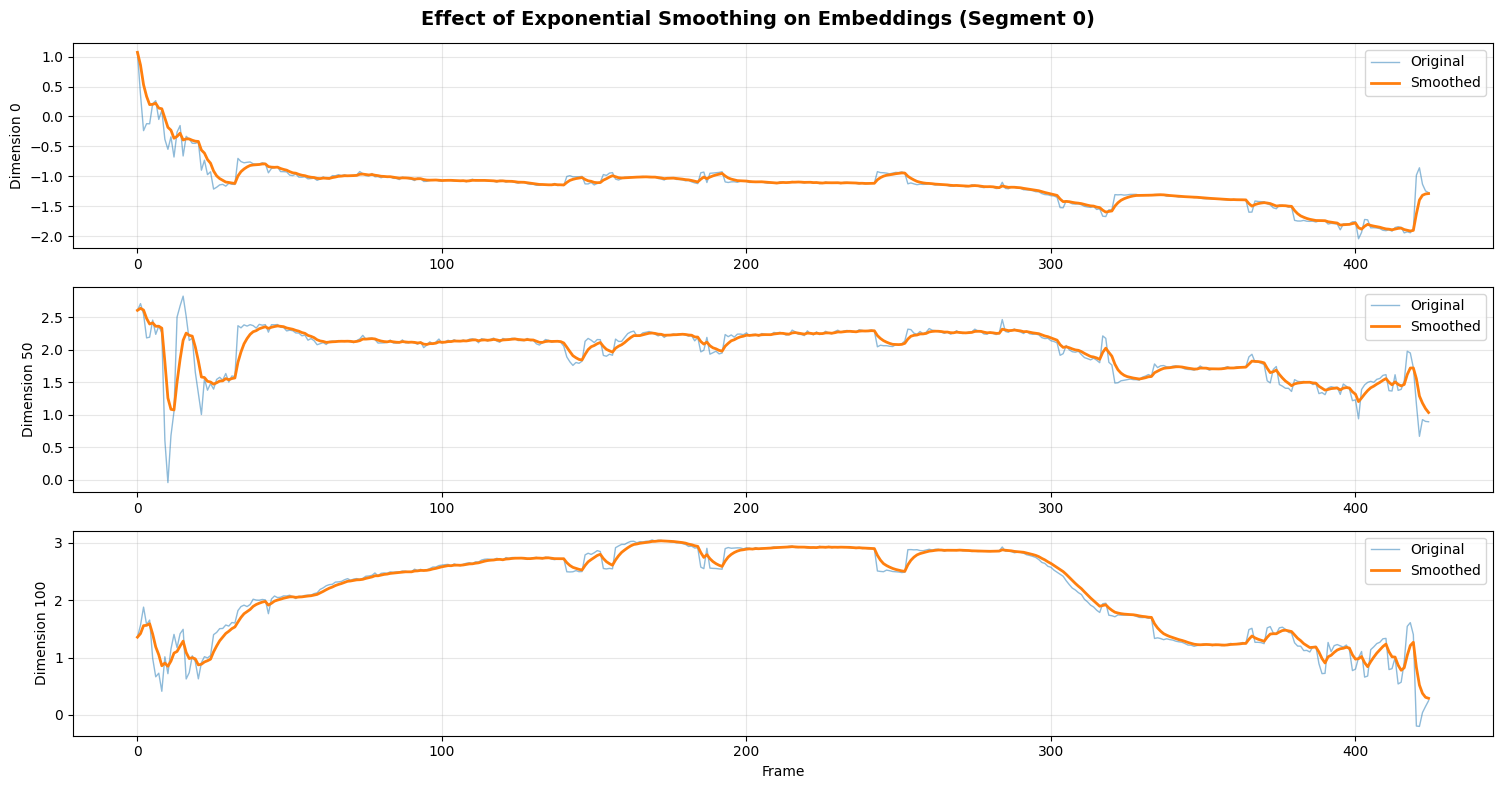

In [12]:
# Visualize the effect of smoothing on a few dimensions from the first segment
seg_0_original = segs[0]
seg_0_smoothed = segs_smoothed[0]

fig, axes = plt.subplots(3, 1, figsize=(15, 8))
dims_to_plot = [0, min(50, seg_0_original.shape[1]-1), min(100, seg_0_original.shape[1]-1)]

for i, dim in enumerate(dims_to_plot):
    axes[i].plot(seg_0_original.iloc[:, dim], alpha=0.5, label='Original', linewidth=1)
    axes[i].plot(seg_0_smoothed.iloc[:, dim], label='Smoothed', linewidth=2)
    axes[i].set_ylabel(f'Dimension {dim}')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

axes[-1].set_xlabel('Frame')
plt.suptitle('Effect of Exponential Smoothing on Embeddings (Segment 0)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Hierarchical Clustering
Apply agglomerative hierarchical clustering to the smoothed embeddings

In [ ]:
# Perform hierarchical clustering with different linkage methods on combined smoothed embeddings
# Use only the embedding columns (exclude segment_id)
embedding_cols = [col for col in df.columns if col != 'segment_id']
df_smoothed = df[embedding_cols]

linkage_methods = ['ward', 'complete']

linkage_results = {}
for method in linkage_methods:
    print(f"Computing linkage with method: {method}")
    Z = linkage(df_smoothed, method=method)
    linkage_results[method] = Z
    
print("Linkage computation complete!")
print(f"Clustering performed on {df_smoothed.shape[0]} frames with {df_smoothed.shape[1]} dimensions")

Computing linkage with method: ward
Linkage computation complete!
Clustering performed on 23627 frames with 256 dimensions
Linkage computation complete!
Clustering performed on 23627 frames with 256 dimensions


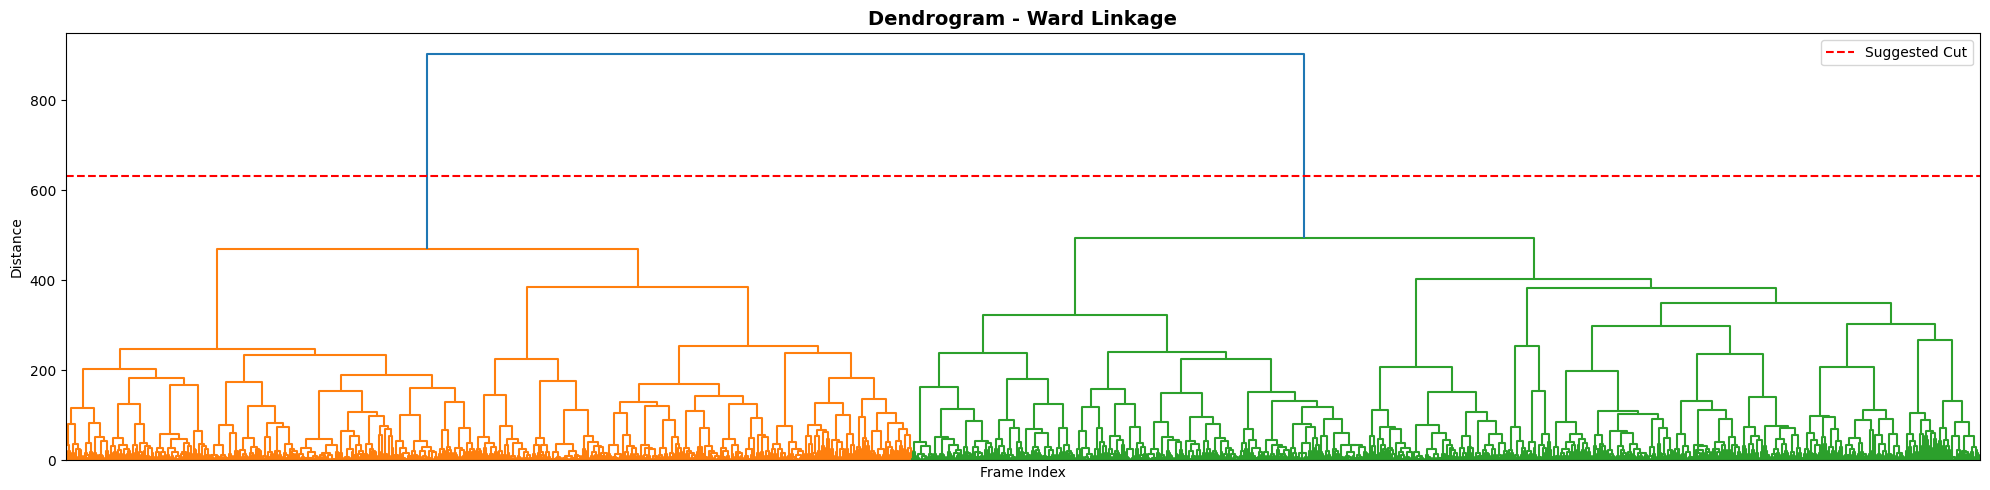

In [25]:
# Visualize dendrograms for each linkage method
fig, axes = plt.subplots(len(linkage_methods), 1, figsize=(20, 5*len(linkage_methods)))

if len(linkage_methods) == 1:
    axes = [axes]

for idx, (method, Z) in enumerate(linkage_results.items()):
    dendrogram(Z, ax=axes[idx], color_threshold=0.7*max(Z[:,2]), no_labels=True)
    axes[idx].set_title(f'Dendrogram - {method.capitalize()} Linkage', fontsize=14, fontweight='bold')
    axes[idx].set_xlabel('Frame Index')
    axes[idx].set_ylabel('Distance')
    axes[idx].axhline(y=0.7*max(Z[:,2]), color='r', linestyle='--', label='Suggested Cut')
    axes[idx].legend()

plt.tight_layout()
plt.show()

## Clustering Quality Metrics
Evaluate clustering quality for different numbers of clusters using multiple metrics:
- **Silhouette Score**: Measures how similar a point is to its own cluster compared to other clusters (higher is better, range [-1, 1])
- **Calinski-Harabasz Index**: Ratio of between-cluster to within-cluster dispersion (higher is better)
- **Davies-Bouldin Index**: Average similarity between each cluster and its most similar cluster (lower is better)

In [28]:
def evaluate_clustering(data, linkage_matrix, n_clusters_range):
    """
    Evaluate clustering quality for different numbers of clusters.
    
    Returns metrics dataframe with columns:
    - n_clusters
    - silhouette_score
    - calinski_harabasz_score
    - davies_bouldin_score
    """
    results = []
    
    for n_clusters in n_clusters_range:
        # Get cluster labels
        labels = fcluster(linkage_matrix, n_clusters, criterion='maxclust')
        
        # Calculate metrics (need at least 2 clusters)
        if n_clusters >= 2 and len(np.unique(labels)) >= 2:
            sil_score = silhouette_score(data, labels)
            ch_score = calinski_harabasz_score(data, labels)
            db_score = davies_bouldin_score(data, labels)
            
            results.append({
                'n_clusters': n_clusters,
                'silhouette_score': sil_score,
                'calinski_harabasz_score': ch_score,
                'davies_bouldin_score': db_score,
                'n_actual_clusters': len(np.unique(labels))
            })
    
    return pd.DataFrame(results)

# Evaluate for different numbers of clusters (2 to 20)
n_clusters_range = range(10, 60)

metrics_results = {}
for method, Z in linkage_results.items():
    print(f"Evaluating {method} linkage...")
    metrics_results[method] = evaluate_clustering(df_smoothed.values, Z, n_clusters_range)
    
print("Evaluation complete!")

Evaluating ward linkage...
Evaluation complete!
Evaluation complete!


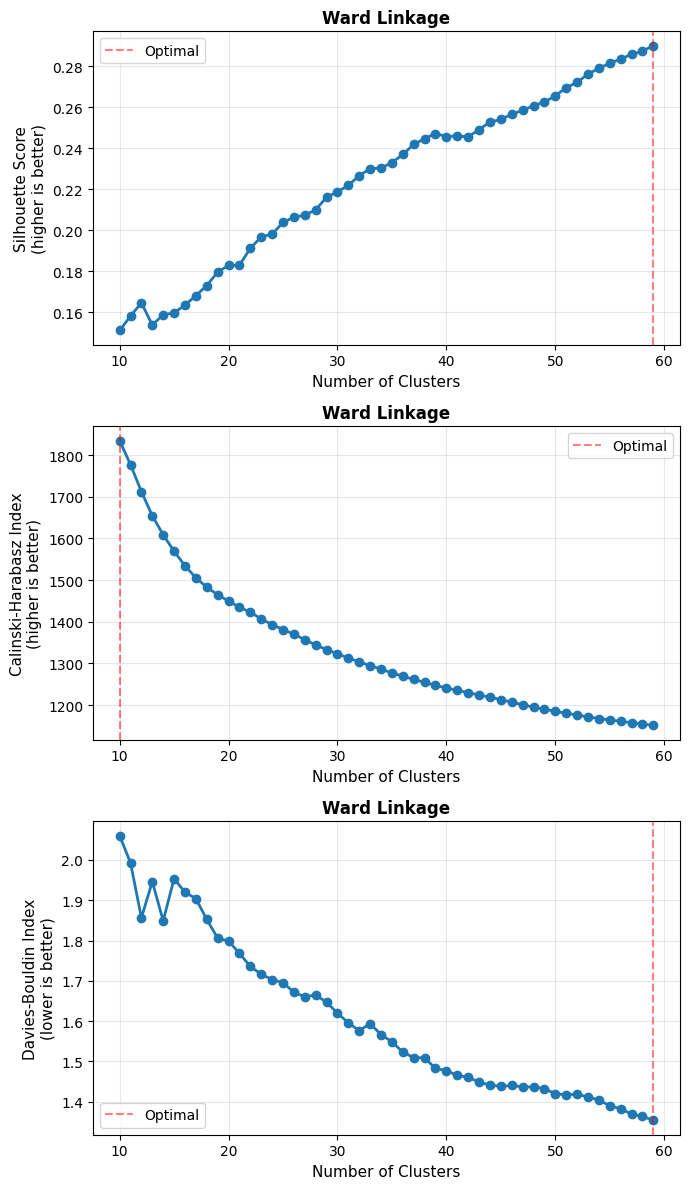

In [29]:
# Plot metrics for each linkage method
fig, axes = plt.subplots(3, len(linkage_methods), figsize=(7*len(linkage_methods), 12))

if len(linkage_methods) == 1:
    axes = axes.reshape(-1, 1)

metric_names = ['silhouette_score', 'calinski_harabasz_score', 'davies_bouldin_score']
metric_labels = ['Silhouette Score\n(higher is better)', 
                 'Calinski-Harabasz Index\n(higher is better)', 
                 'Davies-Bouldin Index\n(lower is better)']

for col_idx, (method, metrics_df) in enumerate(metrics_results.items()):
    for row_idx, (metric, label) in enumerate(zip(metric_names, metric_labels)):
        ax = axes[row_idx, col_idx]
        ax.plot(metrics_df['n_clusters'], metrics_df[metric], 'o-', linewidth=2, markersize=6)
        
        # Mark the optimal value
        if metric == 'davies_bouldin_score':
            optimal_idx = metrics_df[metric].idxmin()
            ax.axvline(metrics_df.loc[optimal_idx, 'n_clusters'], 
                      color='r', linestyle='--', alpha=0.5, label='Optimal')
        else:
            optimal_idx = metrics_df[metric].idxmax()
            ax.axvline(metrics_df.loc[optimal_idx, 'n_clusters'], 
                      color='r', linestyle='--', alpha=0.5, label='Optimal')
        
        ax.set_xlabel('Number of Clusters', fontsize=11)
        ax.set_ylabel(label, fontsize=11)
        ax.set_title(f'{method.capitalize()} Linkage', fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.legend()

plt.tight_layout()
plt.show()

In [18]:
# Summary: Find optimal number of clusters for each method
print("=" * 80)
print("OPTIMAL NUMBER OF CLUSTERS BY METRIC")
print("=" * 80)

for method, metrics_df in metrics_results.items():
    print(f"\n{method.upper()} LINKAGE:")
    print("-" * 40)
    
    # Silhouette (higher is better)
    sil_opt = metrics_df.loc[metrics_df['silhouette_score'].idxmax()]
    print(f"Silhouette Score:      {int(sil_opt['n_clusters'])} clusters (score: {sil_opt['silhouette_score']:.4f})")
    
    # Calinski-Harabasz (higher is better)
    ch_opt = metrics_df.loc[metrics_df['calinski_harabasz_score'].idxmax()]
    print(f"Calinski-Harabasz:     {int(ch_opt['n_clusters'])} clusters (score: {ch_opt['calinski_harabasz_score']:.2f})")
    
    # Davies-Bouldin (lower is better)
    db_opt = metrics_df.loc[metrics_df['davies_bouldin_score'].idxmin()]
    print(f"Davies-Bouldin:        {int(db_opt['n_clusters'])} clusters (score: {db_opt['davies_bouldin_score']:.4f})")
    
    # Consensus suggestion (most common optimal value)
    optimal_values = [int(sil_opt['n_clusters']), int(ch_opt['n_clusters']), int(db_opt['n_clusters'])]
    from collections import Counter
    consensus = Counter(optimal_values).most_common(1)[0][0]
    print(f"\n→ Recommended:         {consensus} clusters")

print("\n" + "=" * 80)

OPTIMAL NUMBER OF CLUSTERS BY METRIC

WARD LINKAGE:
----------------------------------------
Silhouette Score:      20 clusters (score: 0.1828)
Calinski-Harabasz:     2 clusters (score: 4606.57)
Davies-Bouldin:        20 clusters (score: 1.7984)

→ Recommended:         20 clusters

AVERAGE LINKAGE:
----------------------------------------
Silhouette Score:      2 clusters (score: 0.2827)
Calinski-Harabasz:     7 clusters (score: 1216.55)
Davies-Bouldin:        2 clusters (score: 1.1890)

→ Recommended:         2 clusters

COMPLETE LINKAGE:
----------------------------------------
Silhouette Score:      2 clusters (score: 0.2363)
Calinski-Harabasz:     4 clusters (score: 1977.61)
Davies-Bouldin:        3 clusters (score: 1.3112)

→ Recommended:         2 clusters



## Visualize Final Clustering
Apply the optimal clustering and visualize the temporal segmentation

In [19]:
# Choose the best method (ward is typically good for video segmentation)
best_method = 'ward'
best_linkage = linkage_results[best_method]

# Get optimal number of clusters based on silhouette score
optimal_n = int(metrics_results[best_method].loc[
    metrics_results[best_method]['silhouette_score'].idxmax(), 'n_clusters'])

# Get cluster labels
cluster_labels = fcluster(best_linkage, optimal_n, criterion='maxclust')

# Add to dataframe
df_smoothed['cluster'] = cluster_labels

print(f"Using {best_method} linkage with {optimal_n} clusters")
print(f"Cluster distribution:")
print(pd.Series(cluster_labels).value_counts().sort_index())

Using ward linkage with 20 clusters
Cluster distribution:
1     1784
2     1086
3     2203
4     1618
5     2014
6      419
7     1324
8     1007
9     1015
10     868
11    2746
12    1731
13     209
14     315
15    1513
16     838
17     741
18    1271
19     408
20     517
Name: count, dtype: int64


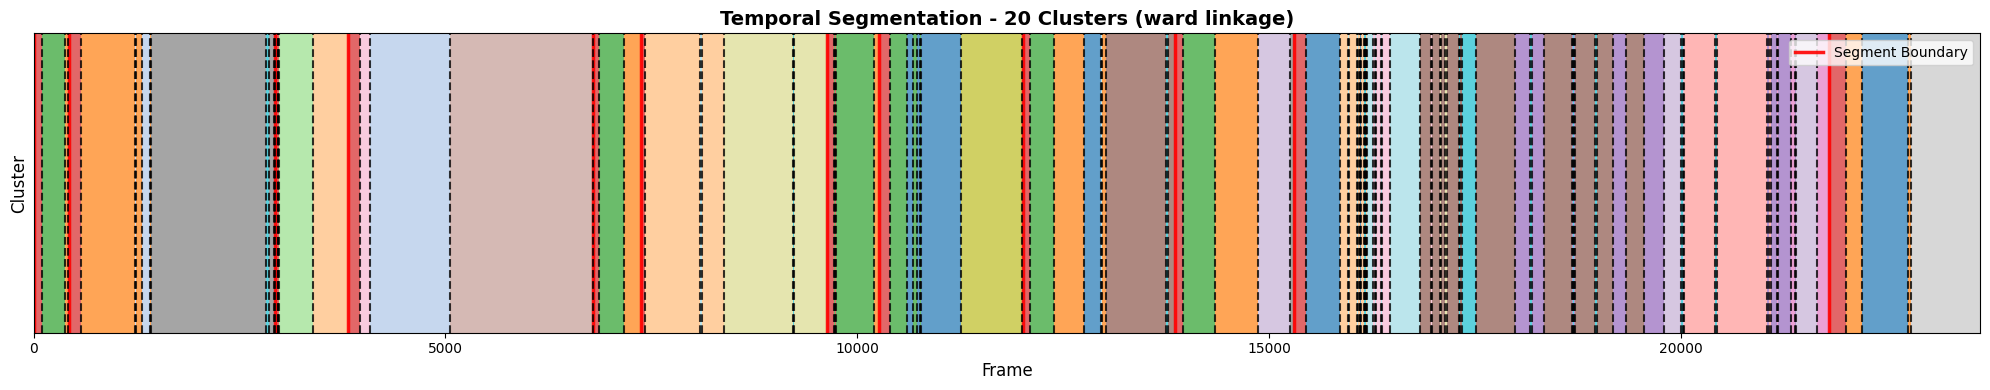


Number of cluster transitions: 127
Number of segment boundaries: 12
Cluster transition points (frames): [99, 382, 420, 574, 1237, 1248, 1319, 1419, 1426, 2826, 2853, 2918, 2929, 2933, 2969, 2972, 2978, 3394, 3811, 3960, 4085, 5060, 6791, 6793, 6865, 7163, 7376, 7423, 8095, 8110, 8375, 9217, 9231, 9630, 9712, 9726, 9744, 10197, 10258, 10395, 10603, 10676, 10724, 10757, 10777, 11257, 11998, 12016, 12092, 12385, 12750, 12961, 12974, 13015, 13742, 13766, 13859, 13949, 14346, 14860, 15252, 15300, 15446, 15860, 15958, 15966, 16059, 16072, 16101, 16104, 16114, 16145, 16156, 16162, 16168, 16174, 16181, 16261, 16278, 16292, 16354, 16371, 16467, 16824, 16967, 16978, 17076, 17087, 17137, 17156, 17307, 17315, 17341, 17509, 17978, 18170, 18189, 18340, 18678, 18689, 18700, 18710, 18948, 18982, 19174, 19333, 19552, 19787, 19992, 20018, 20035, 20408, 20436, 21040, 21061, 21091, 21166, 21178, 21328, 21383, 21394, 21648, 21790, 22002, 22192, 22749, 22789]
Segment boundary points (frames): [0, 425, 2929

In [20]:
# Visualize temporal segmentation with segment boundaries
fig, ax = plt.subplots(figsize=(20, 4))

# Create color map
colors = plt.cm.tab20(np.linspace(0, 1, optimal_n))
cluster_colors = [colors[c-1] for c in cluster_labels]

# Plot clusters as colored segments
for i in range(len(cluster_labels)):
    ax.axvspan(i, i+1, facecolor=cluster_colors[i], alpha=0.7)

# Mark original segment boundaries
segment_boundaries = df['segment_id'].diff()
segment_transitions = segment_boundaries[segment_boundaries != 0].index.tolist()
for t in segment_transitions:
    ax.axvline(t, color='red', linestyle='-', linewidth=2.5, alpha=0.9, label='Segment Boundary' if t == segment_transitions[0] else '')

ax.set_xlabel('Frame', fontsize=12)
ax.set_ylabel('Cluster', fontsize=12)
ax.set_title(f'Temporal Segmentation - {optimal_n} Clusters ({best_method} linkage)', 
             fontsize=14, fontweight='bold')
ax.set_xlim(0, len(cluster_labels))
ax.set_ylim(0, 1)
ax.set_yticks([])

# Add cluster transitions
transitions = np.where(np.diff(cluster_labels) != 0)[0] + 1
for t in transitions:
    if t not in segment_transitions:  # Don't draw twice on segment boundaries
        ax.axvline(t, color='black', linestyle='--', linewidth=1.5, alpha=0.8)

# Add legend
if segment_transitions:
    ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

print(f"\nNumber of cluster transitions: {len(transitions)}")
print(f"Number of segment boundaries: {len(segment_transitions)}")
print(f"Cluster transition points (frames): {transitions.tolist()}")
print(f"Segment boundary points (frames): {segment_transitions}")

In [21]:
# Save results
results_summary = {
    'method': best_method,
    'optimal_clusters': optimal_n,
    'alpha_smoothing': 0.3,
    'n_segments': len(segs),
    'total_frames': len(cluster_labels),
    'cluster_labels': cluster_labels,
    'transitions': transitions.tolist(),
    'metrics': metrics_results[best_method].to_dict('records')
}

# Save cluster labels to CSV with segment information
df_output = df_smoothed.copy()
df_output['segment_id'] = df['segment_id']
df_output['cluster'] = cluster_labels
output_file = out / f"cluster_labels_{best_method}_{optimal_n}clusters.csv"
df_output[['segment_id', 'cluster']].to_csv(output_file)
print(f"\nCluster labels saved to: {output_file}")

# Save metrics
metrics_file = out / f"clustering_metrics_{best_method}.csv"
metrics_results[best_method].to_csv(metrics_file, index=False)
print(f"Clustering metrics saved to: {metrics_file}")

# Save summary
import json
summary_file = out / f"clustering_summary_{best_method}.json"
with open(summary_file, 'w') as f:
    json.dump(results_summary, f, indent=2)
print(f"Summary saved to: {summary_file}")


Cluster labels saved to: /home/shares/schaerm/schaer2/thibaut/humanlisbet/output/trained_models/real_train/tr/models/lisbet-tr-101225-embedder/embeddings/test/hierarchy_clustering/cluster_labels_ward_20clusters.csv
Clustering metrics saved to: /home/shares/schaerm/schaer2/thibaut/humanlisbet/output/trained_models/real_train/tr/models/lisbet-tr-101225-embedder/embeddings/test/hierarchy_clustering/clustering_metrics_ward.csv


TypeError: Object of type ndarray is not JSON serializable